<a href="https://colab.research.google.com/github/AudreyZakiyaT/Audrey-Zakiya-T/blob/main/Tugas_UTS_CPS_Audrey_Zakiya_Trustee_225150307111003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Rangkaian Wireless Power Transfer Tanpa Kompensasi Kapasitor
Nama: Audrey Zakiya Trustee

NIM: 225150307111003

Mata Kuliah: Cyber Physical System

Rangkaian ini merupakan sistem Wireless Power Transfer (WPT) dasar tanpa kompensasi kapasitif, terdiri dari:

- Rangkaian Primer: V1 (AC), R1 = 1.2Ω, LT = 63.46μH  
- Rangkaian Sekunder: R2 = 1.6Ω, LR = 29.2μH, RB = 1kΩ  
- Induktansi Mutual: M = k * sqrt(LT * LR), dengan k = 0.6

Pemodelan dilakukan menggunakan analisis KVL, dilanjutkan transformasi state-space, fungsi alih, respons frekuensi, dan respons waktu.


1. Import Library

In [28]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy.abc import s, t
from IPython.display import display, Markdown


2. Deklarasi Parameter dan Variabel

In [4]:
# Parameter komponen
R1 = 1.2  # Ohm
R2 = 1.6  # Ohm
RB = 1000  # Ohm
LT = 63.46e-6  # Henry
LR = 29.2e-6  # Henry
K = 0.6  # Koefisien kopling
M = K * sp.sqrt(LT * LR)  # Induktansi bersama


3. Analisis KCL dan KVL

Analisis KVL dilakukan untuk menentukan hubungan tegangan dan arus dalam masing-masing loop. Berikut ini adalah persamaan untuk loop primer dan sekunder:


Loop Primer
$$ V1 = R1 \cdot I1 + L_T \cdot \frac{dI1}{dt} + M \cdot \frac{dI2}{dt} $$

Loop Sekunder
$$ 0 = R2 \cdot I2 + L_R \cdot \frac{dI2}{dt} + M \cdot \frac{dI1}{dt} $$


In [18]:
# Definisi variabel
R1, R2, LT, LR, M = sp.symbols('R1 R2 LT LR M')
I1 = sp.Function('I1')(t)
I2 = sp.Function('I2')(t)
V1 = sp.Function('V1')(t)

# Persamaan KVL untuk loop primer
eq1 = sp.Eq(V1, R1*I1 + LT*sp.diff(I1, t) + M*sp.diff(I2, t))

# Persamaan KVL untuk loop sekunder
eq2 = sp.Eq(0, R2*I2 + LR*sp.diff(I2, t) + M*sp.diff(I1, t))

# Menggunakan simplify() untuk membuat rumus lebih rapi
eq1_simplified = sp.simplify(eq1)
eq2_simplified = sp.simplify(eq2)

# Menampilkan rumus dalam format lebih bersih
display(eq1_simplified)
display(eq2_simplified)

Eq(V1(t), LT*Derivative(I1(t), t) + M*Derivative(I2(t), t) + R1*I1(t))

Eq(LR*Derivative(I2(t), t) + M*Derivative(I1(t), t) + R2*I2(t), 0)

4. Representasi State-Space

In [29]:
# Definisikan simbol-simbol yang digunakan
R1, R2, LT, LR, M = sp.symbols('R1 R2 LT LR M')

# Nilai-nilai komponen
R1_val = 1.2  # Ohm
R2_val = 1.6  # Ohm
LT_val = 63.46e-6  # Henry
LR_val = 29.2e-6  # Henry
k = 0.6
M_val = k * np.sqrt(LT_val * LR_val)  # Induktansi mutual

# Matriks keadaan
A = sp.Matrix([[-R1 / LT, -M / LT], [-M / LR, -R2 / LR]])
B = sp.Matrix([[1 / LT], [0]])
C = sp.Matrix([[0, 1]])  # Output: arus sekunder
D = sp.Matrix([[0]])

# Substitusi nilai dan evaluasi numerik
subs = {R1: R1_val, R2: R2_val, LT: LT_val, LR: LR_val, M: M_val}
A_numeric = A.subs(subs).evalf(3)
B_numeric = B.subs(subs).evalf(3)
C_numeric = C.evalf(3)  # Tidak ada substitusi untuk C
D_numeric = D.evalf(3)  # Tidak ada substitusi untuk D

# Format hasil numerik tanpa notasi ilmiah
A_numeric_str = [[f"{val:.3f}" for val in row] for row in A_numeric.tolist()]
B_numeric_str = [[f"{val:.3f}" for val in row] for row in B_numeric.tolist()]
C_numeric_str = [[f"{val:.3f}" for val in row] for row in C_numeric.tolist()]
D_numeric_str = [[f"{val:.3f}" for val in row] for row in D_numeric.tolist()]

# Tampilkan hasil dengan format yang baik
display(Markdown(f"**Matriks A**:\n\n{A_numeric_str}"))
display(Markdown(f"**Matriks B**:\n\n{B_numeric_str}"))
display(Markdown(f"**Matriks C**:\n\n{C_numeric_str}"))
display(Markdown(f"**Matriks D**:\n\n{D_numeric_str}"))

**Matriks A**:

[['-18900.000', '-0.407'], ['-0.885', '-54800.000']]

**Matriks B**:

[['15800.000'], ['0.000']]

**Matriks C**:

[['0.000', '1.000']]

**Matriks D**:

[['0.000']]

**Matriks A**:
$$ A = \begin{bmatrix} -18909.549 & -0.407 \\ -0.885 & -54794.521 \end{bmatrix} $$

**Matriks B**:
$$ B = \begin{bmatrix} 15757.958 \\ 0 \end{bmatrix} $$

**Matriks C**:
$$ C = \begin{bmatrix} 0 & 1 \end{bmatrix} $$

**Matriks D**:
$$ D = \begin{bmatrix} 0 \end{bmatrix} $$


5. Transfer Function

Rumus Fungsi Alih

\[
G(s) = C (sI - A)^{-1} B + D
\]


In [37]:
A = sp.Matrix([[-R1/LT, -M/LT], [-M/LR, -R2/LR]])
B = sp.Matrix([[1/LT], [0]])
C = sp.Matrix([[0, 1]])
D = sp.Matrix([[0]])

# Substitusi nilai numerik ke matriks simbolik
subs_dict = {R1: R1_val, R2: R2_val, LT: LT_val, LR: LR_val, M: M_val}
A_num = A.subs(subs_dict)
B_num = B.subs(subs_dict)
C_num = C
D_num = D

# Hitung transfer function G(s) = C * (sI - A)^-1 * B + D
I = sp.eye(2)
G = C_num * (s * I - A_num).inv() * B_num + D_num
G_simplified = sp.simplify(G[0])
display(sp.Eq(sp.Function('G')(s), G_simplified))  # Menampilkan G(s) dengan angka

Eq(G(s), -13938.2994539712/(1.0*s**2 + 73704.069870353*s + 1036139688.53906))

6. Respon Frekuensi

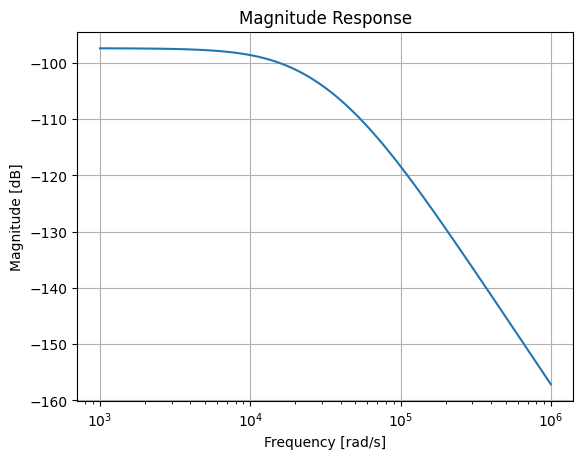

<Figure size 800x500 with 0 Axes>

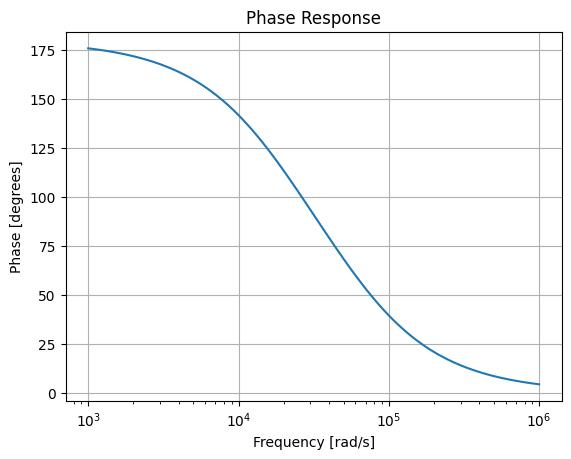

In [40]:
# Definisikan sistem dalam bentuk numerik untuk analisis frekuensi
A_np = np.array(A_num).astype(np.float64)
B_np = np.array(B_num).astype(np.float64)
C_np = np.array(C_num).astype(np.float64)
D_np = np.array(D_num).astype(np.float64)

system = signal.StateSpace(A_np, B_np, C_np, D_np)
w, mag, phase = signal.bode(system)

# Plot respon frekuensi (Bode Plot)
plt.figure()
plt.semilogx(w, mag)
plt.title('Magnitude Response')
plt.xlabel('Frequency [rad/s]')
plt.ylabel('Magnitude [dB]')
plt.grid(True)

plt.figure(figsize=(8, 5))
plt.figure()
plt.semilogx(w, phase)
plt.title('Phase Response')
plt.xlabel('Frequency [rad/s]')
plt.ylabel('Phase [degrees]')
plt.grid(True)
plt.show()

7. Respon Waktu

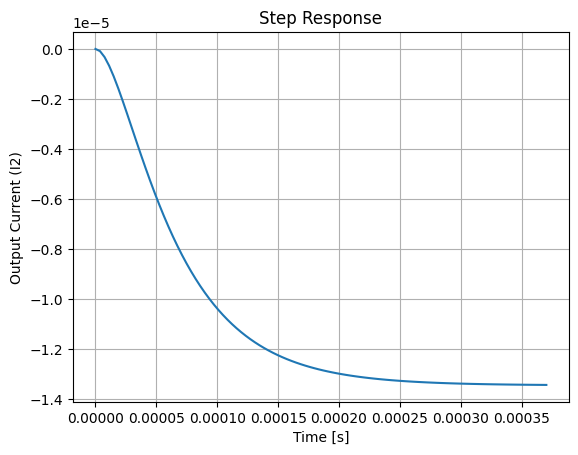

In [50]:
t_out, y_out = signal.step(system)

plt.plot(t_out, y_out)
plt.title('Step Response')
plt.xlabel('Time [s]')
plt.ylabel('Output Current (I2)')
plt.grid(True)
plt.show()


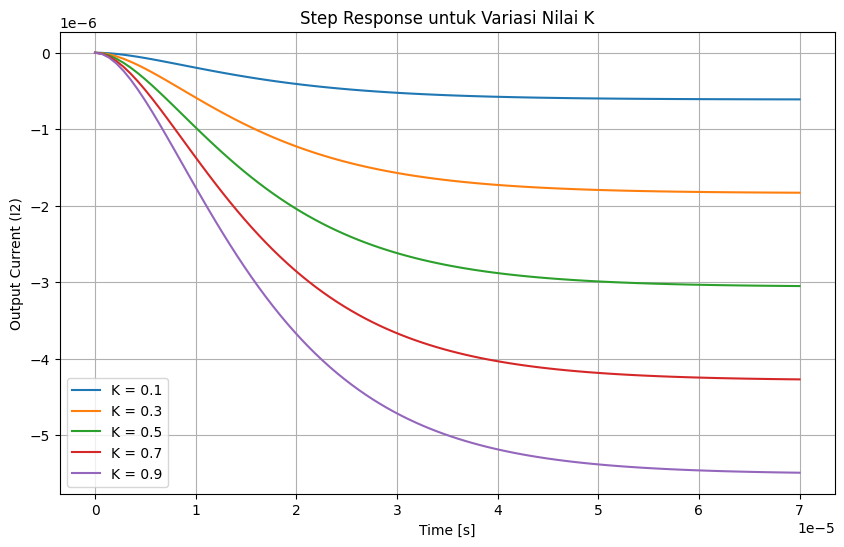

In [51]:
# Definisi parameter dasar
L1 = 10e-6  # Induktansi primer (H)
L2 = 15e-6  # Induktansi sekunder (H)
R1 = 1      # Resistansi primer (Ohm)
R2 = 2      # Resistansi sekunder (Ohm)
LT = L1     # Total L sisi primer
LR = L2     # Total L sisi sekunder

# Step Response untuk beberapa nilai K (variasi)
k_values = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(10, 6))

for k in k_values:
    M_var = k * np.sqrt(L1 * L2)  # Variasikan M berdasarkan K
    A_var = np.array([
        [-R1 / LT, -M_var / LT],
        [-M_var / LR, -R2 / LR]
    ])
    B_var = np.array([[1 / LT], [0]])  # Input untuk sistem
    C_var = np.array([[0, 1]])  # Output untuk sistem
    D_var = np.array([[0]])  # Tidak ada direct transmission

    # Membuat sistem keadaan untuk variasi K
    system_var = signal.StateSpace(A_var, B_var, C_var, D_var)
    t_out, y_out = signal.step(system_var)

    # Plot hasil step response untuk setiap nilai K
    plt.plot(t_out, y_out, label=f'K = {k}')

# Pengaturan plot
plt.title('Step Response untuk Variasi Nilai K')
plt.xlabel('Time [s]')
plt.ylabel('Output Current (I2)')
plt.legend()  # Menampilkan legenda
plt.grid(True)  # Menampilkan grid
plt.show()  # Menampilkan plot

## Variasi Respon Waktu dengan Nilai K Berbeda

Dengan memvariasikan nilai \( K \) dari 0.1 hingga 0.9, kita dapat mengamati perubahan respon waktu sistem. Semakin besar nilai \( K \), maka efek kopling antara induktor meningkat, yang dapat mempengaruhi kecepatan respons sistem atau overshoot. Grafik di bawah menunjukkan pengaruh tersebut secara visual.
